In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

from utils.tools import *

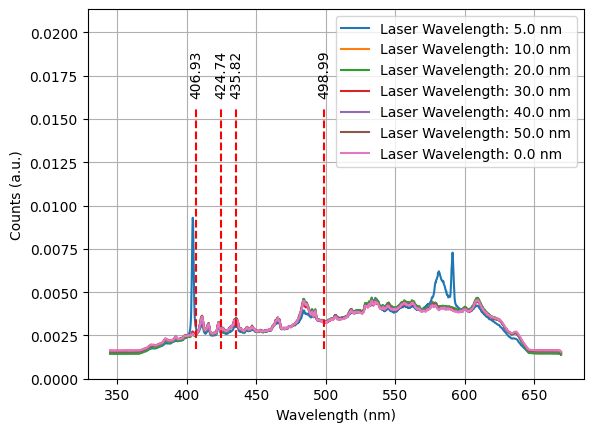

In [2]:
root = os.getcwd()
method = "Wavelength Scan"
method = os.path.join(method, "RLIBS")
date = "8_4_26"
atom = "Nd_I"
top_n_lines = 4

path = os.path.join(root, method)
path = os.path.join(path, date)
results_path = os.path.join(root, "Results")
results_path = os.path.join(results_path, date)

results = {}
spectral_max = -np.inf
plotted_scan_wavelength = []

fig, ax = plt.subplots(1)

for file in os.listdir(path):
    file_path = os.path.join(path, file)

    wavelength, spectrum = read_spe(file_path)
    total_area = np.trapezoid(spectrum, wavelength)
    spectrum = spectrum / total_area

    if spectral_max < spectrum.max():
        spectral_max = spectrum.max()
    

    scan_wavelength = file_to_wavelength(file)

    if scan_wavelength not in plotted_scan_wavelength:
        ax.plot(wavelength, spectrum, label = f"Laser Wavelength: {scan_wavelength} nm")
        plotted_scan_wavelength.append(scan_wavelength)

    results[file] = {
        "wavelength": wavelength,
        "spectrum": spectrum,
        "scan_wavelength": scan_wavelength
    }


lines_df = read_referenece_lines(atom, wavelength, top_n_lines = top_n_lines)

ax.vlines(lines_df["wavelength"], ymin = spectrum.min(), ymax = 1.1 * spectral_max, linestyles = "--", color = "red")

for wl in lines_df["wavelength"]:
    ax.text(wl, 1.15 * spectral_max, f"{round(wl, 2)}", rotation = "vertical", ha = "center")

ax.grid(True)
ax.legend()
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Counts (a.u.)")
ax.set_ylim(0, 1.5 * spectral_max)
plt.show()

In [6]:
N_points = 21
N_fit = 512
lamb0 = 468.35
fit_method = "voigt"
maxfev = 5000

debug = False

fit_param_names = {
    "gaussian":   ["A", "mu", "sigma", "a", "b"],
    "lorentzian": ["A", "mu", "gamma", "a", "b"],
    "voigt":      ["A", "mu", "sigma", "gamma", "a", "b"],
}


for file in results.keys():
    print("=" * 50)
    print(f"Fitting: {file}")
    print("=" * 50)
    data = results[file]

    x = data["wavelength"]
    y = data["spectrum"]
    idx = np.argmin(np.abs(x - lamb0))
    x = x[idx - N_points // 2 : idx + N_points // 2]
    y = y[idx - N_points // 2 : idx + N_points // 2]

    p0 = initial_guess(x, y, mode = fit_method)
    bounds = set_bounds(x, y, p0, mode = fit_method)

    if fit_method == "gaussian":
        fit_func = gaussian_fit

    elif fit_method == "lorentzian":
        fit_func = lorentzian_fit

    elif fit_method == "voigt":
        fit_func = voigt_fit

    try:
        params, pcov = curve_fit(fit_func, x, y, p0 = p0, bounds = bounds, maxfev = maxfev)
        x_fit = np.linspace(x.min(), x.max(), N_fit)
        y_fit = fit_func(x_fit, *params)

    except Exception as e:
        print(f"An error occurred: {e}")

        fig, ax = plt.subplots(1)
        ax.plot(x, y, "o")
        ax.grid(True)
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Counts (a.u.)")
        ax.set_title(f"Failed Fit: {file}")
        plt.show()
        continue

    if debug:
        fig, ax = plt.subplots(1)
        ax.plot(x, y, "o", color = "black")
        ax.plot(x_fit, y_fit, color = "red")
        ax.grid(True)
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Counts (a.u.)")
        ax.set_title(f"Debug Plot: {file}")
        plt.show()

    area = compute_area(x, params, mode = fit_method)
    results[file]["area"] = area

    y_fit = fit_func(x, *params)
    r2 = compute_r2(y, y_fit)
    results[file]["R2"] = r2
    print(f"R^2: {round(r2, 3)}")

    for name, value in zip(fit_param_names[fit_method], params):
        print(f"{name}: {round(value, 3)}")
        results[file][name] = value
    
    print(f"area: {round(area, 3)}")
    print("=" * 50)

Fitting: rlibs_005_1.SPE
R^2: 0.628
A: 0.0
mu: 466.354
sigma: 3.731
gamma: 3.731
a: -0.0
b: 0.054
area: 0.0
Fitting: rlibs_005_2.SPE
R^2: 0.633
A: 0.0
mu: 466.354
sigma: 3.731
gamma: 3.731
a: -0.0
b: 0.052
area: 0.0
Fitting: rlibs_005_3.SPE
R^2: 0.608
A: 0.0
mu: 466.354
sigma: 3.731
gamma: 3.731
a: -0.0
b: 0.053
area: 0.0
Fitting: rlibs_005_4.SPE
R^2: 0.637
A: 0.0
mu: 466.354
sigma: 3.731
gamma: 3.731
a: -0.0
b: 0.052
area: 0.0
Fitting: rlibs_005_5.SPE
R^2: 0.401
A: 0.0
mu: 470.084
sigma: 3.731
gamma: 3.731
a: -0.0
b: 0.02
area: 0.0
Fitting: rlibs_01_1.SPE
R^2: 0.726
A: 0.0
mu: 466.354
sigma: 3.731
gamma: 3.731
a: -0.0
b: 0.067
area: 0.0
Fitting: rlibs_01_2.SPE
R^2: 0.669
A: 0.0
mu: 466.354
sigma: 3.731
gamma: 3.731
a: -0.0
b: 0.074
area: 0.0
Fitting: rlibs_01_3.SPE
R^2: 0.68
A: 0.0
mu: 466.354
sigma: 3.731
gamma: 3.731
a: -0.0
b: 0.07
area: 0.0
Fitting: rlibs_01_4.SPE
R^2: 0.7
A: 0.0
mu: 466.792
sigma: 1.837
gamma: 0.927
a: -0.0
b: 0.081
area: 0.0
Fitting: rlibs_01_5.SPE
R^2: 0.364
A:

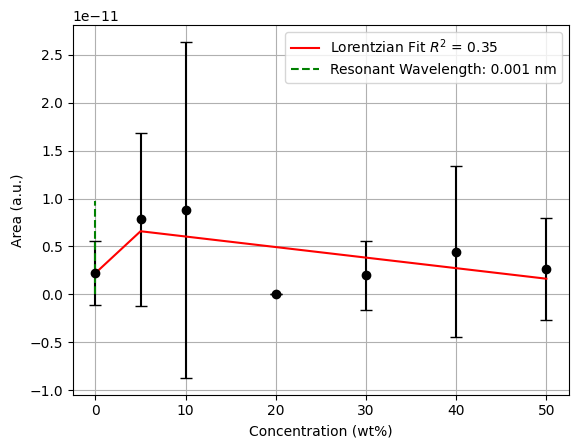

In [7]:
r2_limit = 0.5

areas = np.array([results[file]["area"] for file in results.keys()])
scan_wavelengths = np.array([results[file]["scan_wavelength"] for file in results.keys()])
r2_values = np.array([results[file]["R2"] for file in results.keys()])

mask = r2_values >= r2_limit
areas = areas[mask]
scan_wavelengths = scan_wavelengths[mask]

unique_scan_wavelengths, indexes = np.unique(scan_wavelengths, return_inverse = True)
mean_areas = np.array([np.mean(areas[indexes == i]) for i in range(len(unique_scan_wavelengths))])
std_areas = np.array([np.std(areas[indexes == i], ddof = 1) for i in range(len(unique_scan_wavelengths))])

params, _ = curve_fit(lorentzian_fit, unique_scan_wavelengths, mean_areas)

areas_fit = lorentzian_fit(unique_scan_wavelengths, *params)
r2 = compute_r2(mean_areas, areas_fit)

fig, ax = plt.subplots(1)
ax.errorbar(unique_scan_wavelengths, mean_areas, yerr = std_areas, fmt = "o", capsize = 4, color = "black")
ax.plot(unique_scan_wavelengths, areas_fit, color = "red", label = f"Lorentzian Fit $R^2$ = {round(r2, 3)}")
ax.vlines(params[1], ymin = 0.0, ymax = 1.1 * mean_areas.max(), linestyles = "--", color = "green", label = f"Resonant Wavelength: {round(params[1], 3)} nm")

ax.grid(True)
ax.legend()
ax.set_xlabel("Concentration (wt%)")
ax.set_ylabel("Area (a.u.)")
plt.show()

In [8]:
unique_scan_wavelengths

array([ 0.,  5., 10., 20., 30., 40., 50.])